In [72]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline
import seaborn as sns
from scipy import stats



In [73]:
import pandas as pd

df = pd.read_csv("../data/outputs/provider_level.csv")
df

,billing_provider_npi,cohort_label,months_observed,first_month,last_month,span_months,missing_months_within_span,fraction_months_observed,mean_gap_months,max_gap_months,...,hcpcs_paid_hhi_minus_claim_hhi_t_changepoint_count,hcpcs_paid_hhi_minus_claim_hhi_t_largest_level_shift,hcpcs_paid_hhi_minus_claim_hhi_t_largest_relative_level_shift,hcpcs_paid_hhi_minus_claim_hhi_t_max_abs_robust_z,hcpcs_paid_hhi_minus_claim_hhi_t_num_flagged_months,hcpcs_paid_hhi_minus_claim_hhi_t_fraction_flagged_months,hcpcs_paid_hhi_minus_claim_hhi_t_num_flagged_last_k_obs,hcpcs_paid_hhi_minus_claim_hhi_t_max_consecutive_flagged_obs,insufficient_history_flag,label
0,1003006180,NV_organization,84,2018-01,2024-12,84,0,1.000000,1.000000,1.0,...,5.0,0.051869,0.051869,160.946541,31,0.382716,3.0,8,0,0
1,1003011313,NV_organization,29,2018-01,2022-02,50,21,0.580000,1.750000,6.0,...,0.0,0.000000,0.000000,11.108287,1,0.038462,0.0,1,0,0
2,1003023508,NV_organization,34,2018-01,2020-11,35,1,0.971429,1.030303,2.0,...,0.0,0.000000,0.000000,2.453268,0,0.000000,0.0,0,0,0
3,1003086273,NV_organization,75,2018-04,2024-11,80,5,0.937500,1.067568,5.0,...,2.0,0.120788,0.120788,67.961313,28,0.388889,3.0,4,0,0
4,1003090705,NV_organization,9,2018-02,2020-03,26,17,0.346154,3.125000,13.0,...,0.0,0.000000,0.000000,NaN,0,0.000000,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3270,1992842660,NV_organization,81,2018-01,2024-09,81,0,1.000000,1.000000,1.0,...,7.0,0.105012,0.105012,68.891623,27,0.346154,3.0,3,0,0
3271,1992886584,NV_organization,6,2021-09,2024-09,37,31,0.162162,7.200000,15.0,...,0.0,0.000000,0.000000,0.937910,0,0.000000,NaN,0,0,0
3272,1992888283,NV_organization,42,2019-01,2024-11,71,29,0.591549,1.707317,7.0,...,0.0,0.000000,0.000000,13.659498,3,0.076923,0.0,1,0,0
3273,1992919237,NV_organization,84,2018-01,2024-12,84,0,1.000000,1.000000,1.0,...,4.0,0.124357,0.124357,228.294689,39,0.481481,1.0,8,0,0


In [74]:
df['label'].value_counts()

label
0    3238
1      37
Name: count, dtype: int64

In [75]:
nan_counts = df.isna().sum()
n = len(df)

cols_to_drop = nan_counts[nan_counts / n > 0.05].index
df = df.drop(columns=cols_to_drop)
df = df.dropna()

dropped_info = nan_counts[cols_to_drop].sort_values(ascending=False).reset_index()
dropped_info.columns = ['column', 'nan_count']
dropped_info['nan_pct'] = (dropped_info['nan_count'] / n * 100).round(2)

from IPython.display import display
import pandas as pd
pd.set_option('display.max_rows', 200)
display(dropped_info)


,column,nan_count,nan_pct
0,top_code_paid_minus_claim_share_t_spike_ratio_...,3275,100.00
1,top_code_paid_minus_beneficiary_share_t_spike_...,3275,100.00
2,top_code_paid_minus_beneficiary_share_t_spike_...,3275,100.00
3,hcpcs_paid_hhi_minus_claim_hhi_t_spike_ratio_m...,3275,100.00
4,hcpcs_paid_hhi_minus_claim_hhi_t_spike_ratio_m...,3275,100.00
5,top_code_paid_minus_claim_share_t_spike_ratio_...,3275,100.00
6,claims_per_beneficiary_proxy_t_max_monthlyized...,2778,84.82
7,claims_per_beneficiary_proxy_t_largest_monthly...,2778,84.82
8,hcpcs_count_t_max_monthlyized_pct_growth,2461,75.15
9,hcpcs_count_t_largest_monthlyized_pct_drop,2461,75.15


In [5]:
missing = df.isna().sum()
missing_rows = df.isna().any(axis=1).sum()
print(f"Rows with at least one NaN: {missing_rows} / {len(df)} ({missing_rows/len(df):.1%})")
missing[missing > 0]


Rows with at least one NaN: 0 / 3162 (0.0%)


Series([], dtype: int64)

In [6]:
df

,billing_provider_npi,cohort_label,months_observed,first_month,last_month,span_months,missing_months_within_span,fraction_months_observed,mean_gap_months,max_gap_months,...,hcpcs_paid_hhi_minus_claim_hhi_t_largest_monthlyized_decrease,hcpcs_paid_hhi_minus_claim_hhi_t_max_abs_deviation_from_median,hcpcs_paid_hhi_minus_claim_hhi_t_changepoint_count,hcpcs_paid_hhi_minus_claim_hhi_t_largest_level_shift,hcpcs_paid_hhi_minus_claim_hhi_t_largest_relative_level_shift,hcpcs_paid_hhi_minus_claim_hhi_t_num_flagged_months,hcpcs_paid_hhi_minus_claim_hhi_t_fraction_flagged_months,hcpcs_paid_hhi_minus_claim_hhi_t_max_consecutive_flagged_obs,insufficient_history_flag,label
0,1003006180,NV_organization,84,2018-01,2024-12,84,0,1.000000,1.000000,1.0,...,0.056812,0.083334,5.0,0.051869,0.051869,31,0.382716,8,0,0
1,1003011313,NV_organization,29,2018-01,2022-02,50,21,0.580000,1.750000,6.0,...,0.169275,0.169275,0.0,0.000000,0.000000,1,0.038462,1,0,0
2,1003023508,NV_organization,34,2018-01,2020-11,35,1,0.971429,1.030303,2.0,...,0.083732,0.224161,0.0,0.000000,0.000000,0,0.000000,0,0,0
3,1003086273,NV_organization,75,2018-04,2024-11,80,5,0.937500,1.067568,5.0,...,0.354369,0.371402,2.0,0.120788,0.120788,28,0.388889,4,0,0
4,1003090705,NV_organization,9,2018-02,2020-03,26,17,0.346154,3.125000,13.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0,0.000000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3269,1992809412,NV_organization,84,2018-01,2024-12,84,0,1.000000,1.000000,1.0,...,0.070515,0.089882,8.0,0.070361,0.070361,34,0.419753,4,0,0
3270,1992842660,NV_organization,81,2018-01,2024-09,81,0,1.000000,1.000000,1.0,...,0.161911,0.116095,7.0,0.105012,0.105012,27,0.346154,3,0,0
3272,1992888283,NV_organization,42,2019-01,2024-11,71,29,0.591549,1.707317,7.0,...,0.435989,0.446049,0.0,0.000000,0.000000,3,0.076923,1,0,0
3273,1992919237,NV_organization,84,2018-01,2024-12,84,0,1.000000,1.000000,1.0,...,0.238126,0.270705,4.0,0.124357,0.124357,39,0.481481,8,0,0


In [7]:
df['label'].value_counts()

label
0    3127
1      35
Name: count, dtype: int64

# PLOTTING

In [43]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np
exclude = [
    'label', 'billing_provider_npi',
    'insufficient_history_flag', 'cohort_label',
    # history support metadata
    'months_observed', 'first_month', 'last_month',
    'span_months', 'missing_months_within_span',
    'fraction_months_observed', 'mean_gap_months', 'max_gap_months',
]

features = [col for col in df.columns if col not in exclude]

rows = []
for feat in features:
    valid = df[['label', feat]].dropna()
    if valid['label'].nunique() < 2:
        continue
    try:
        auc = roc_auc_score(valid['label'], valid[feat])
        auc = max(auc, 1 - auc)  # flip if below 0.5
        rows.append({'feature': feat, 'auroc': round(auc, 4)})
    except Exception:
        continue

auroc_df = pd.DataFrame(rows).sort_values('auroc', ascending=False).reset_index(drop=True)
auroc_df

,feature,auroc
0,paid_per_beneficiary_proxy_t_iqr,0.9003
1,paid_per_beneficiary_proxy_t_mean_abs_monthlyi...,0.9000
2,paid_per_beneficiary_proxy_t_mad,0.8982
3,paid_per_beneficiary_proxy_t_std,0.8980
4,paid_per_beneficiary_proxy_t_median_abs_monthl...,0.8945
...,...,...
547,top_code_paid_share_iqr,0.5032
548,hcpcs_beneficiary_entropy_t_largest_monthlyize...,0.5028
549,hcpcs_beneficiary_hhi_t_largest_monthlyized_in...,0.5028
550,hcpcs_beneficiary_entropy_t_median_abs_monthly...,0.5026


/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_84840/2023361151.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=log_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], width=0.4)
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_84840/2023361151.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


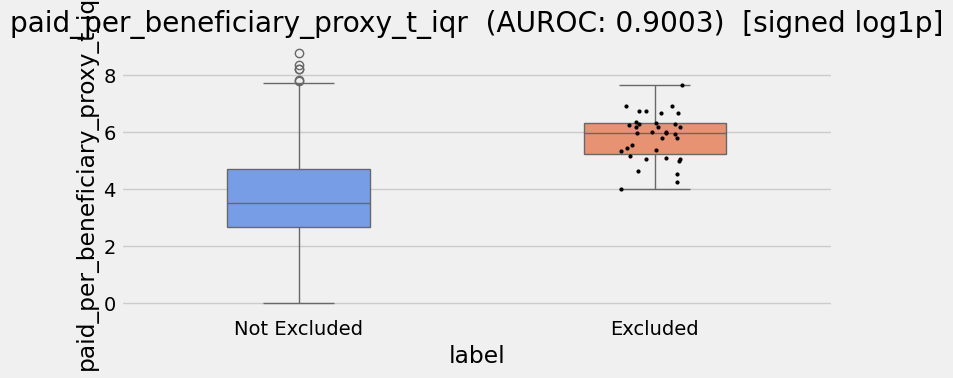

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_84840/2023361151.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=log_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], width=0.4)
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_84840/2023361151.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


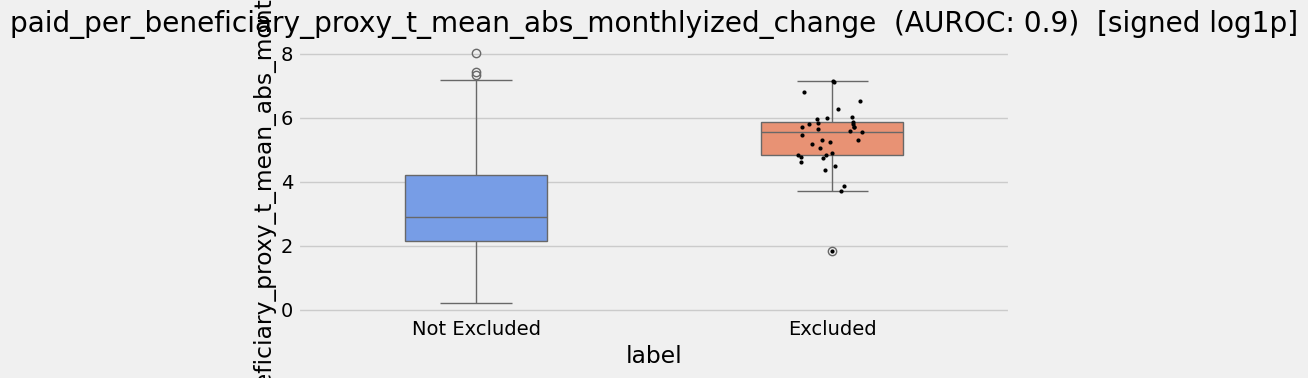

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_84840/2023361151.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=log_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], width=0.4)
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_84840/2023361151.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


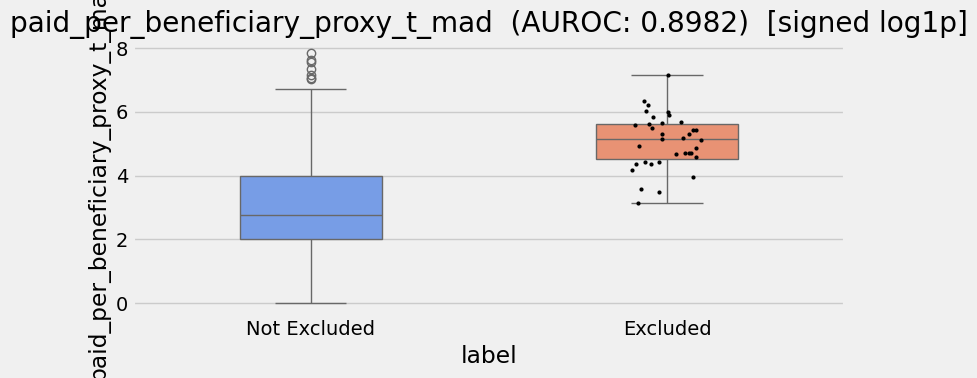

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_84840/2023361151.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=log_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], width=0.4)
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_84840/2023361151.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


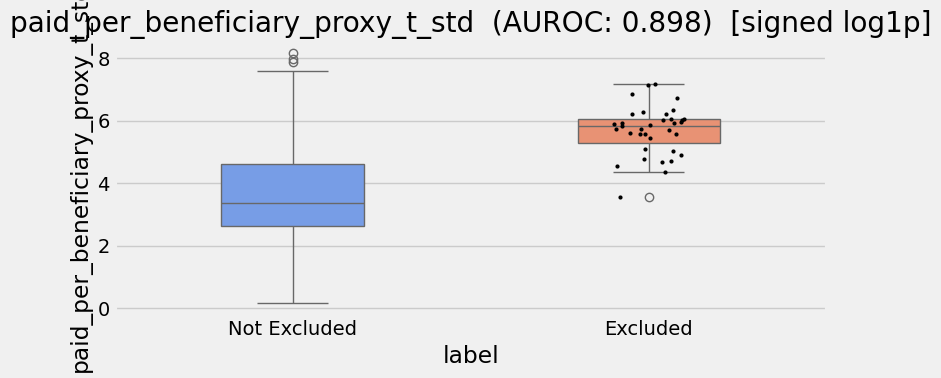

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_84840/2023361151.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=log_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], width=0.4)
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_84840/2023361151.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Excluded', 'Excluded'])


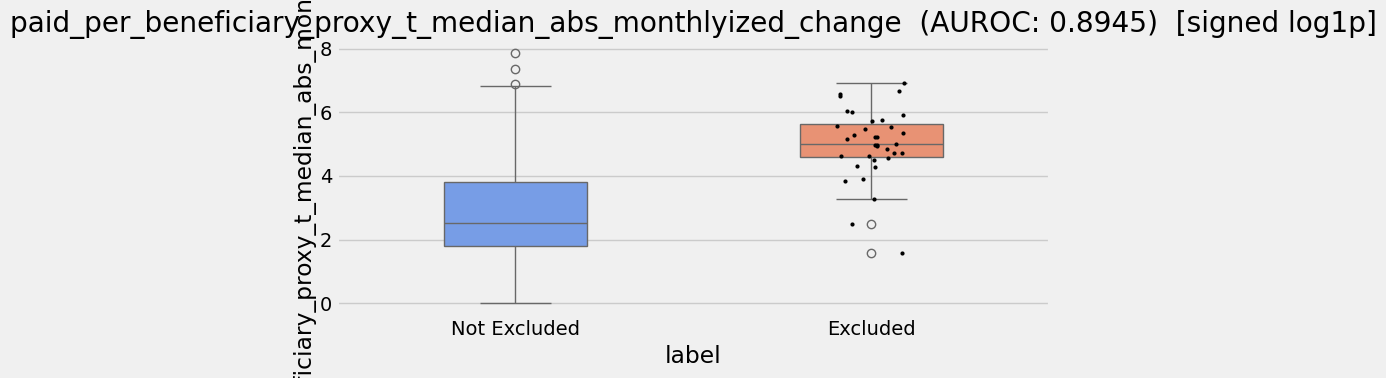

In [9]:
top_features = auroc_df.head(5)['feature'].tolist()
for feat in top_features:
    auc = auroc_df.loc[auroc_df.feature == feat, 'auroc'].values[0]
    plot_df = df[[feat, 'label']].dropna()

    log_df = plot_df.copy()
    log_df[feat] = np.sign(log_df[feat]) * np.log1p(np.abs(log_df[feat]))

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.boxplot(data=log_df, x='label', y=feat, ax=ax, palette=['#6497F9', '#FB8861'], width=0.4)
    sns.stripplot(data=log_df[log_df['label']==1], x='label', y=feat, ax=ax, color='black', size=3, jitter=True)
    ax.set_title(f'{feat}  (AUROC: {auc})  [signed log1p]')
    ax.set_xticklabels(['Not Excluded', 'Excluded'])
    plt.tight_layout()
    plt.show()

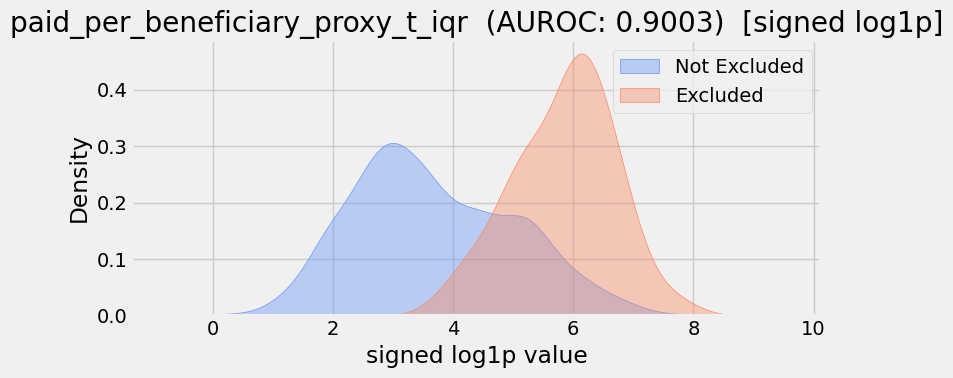

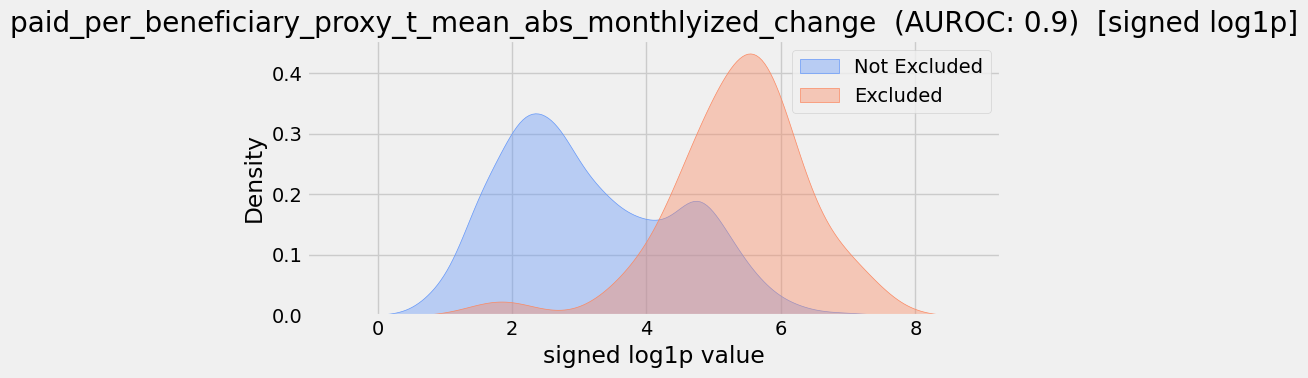

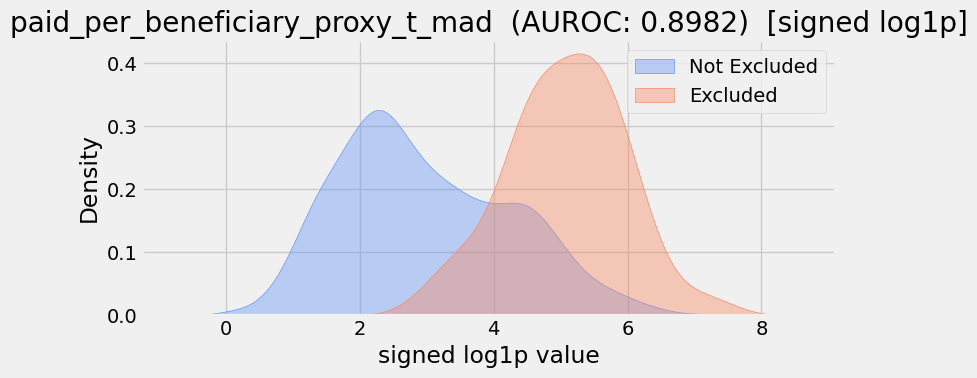

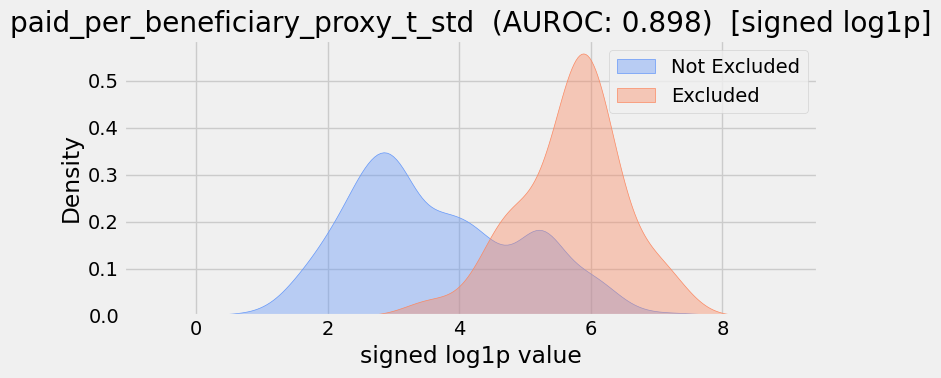

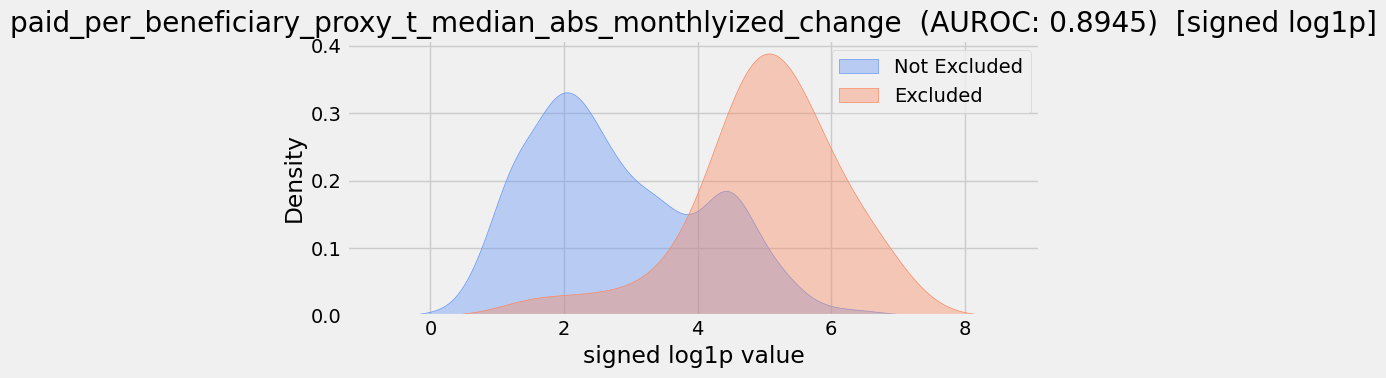

In [12]:


for feat in top_features:
    auc = auroc_df.loc[auroc_df.feature == feat, 'auroc'].values[0]
    plot_df = df[[feat, 'label']].dropna()

    log_df = plot_df.copy()
    log_df[feat] = np.sign(log_df[feat]) * np.log1p(np.abs(log_df[feat]))

    fig, ax = plt.subplots(figsize=(8, 4))
    for label_val, color, name in [(0, '#6497F9', 'Not Excluded'), (1, '#FB8861', 'Excluded')]:
        subset = log_df[log_df['label'] == label_val][feat]
        sns.kdeplot(subset, ax=ax, color=color, label=name, fill=True, alpha=0.4)
    ax.set_title(f'{feat}  (AUROC: {auc})  [signed log1p]')
    ax.set_xlabel('signed log1p value')
    ax.legend()
    plt.tight_layout()
    plt.show()



# Feature Selection

In [13]:
for threshold in [0.4, 0.60, 0.65, 0.70, 0.75, 0.80]:
    n = (auroc_df['auroc'] >= threshold).sum()
    print(f">= {threshold:.2f}: {n} features")


>= 0.40: 552 features
>= 0.60: 192 features
>= 0.65: 94 features
>= 0.70: 65 features
>= 0.75: 53 features
>= 0.80: 38 features


In [81]:
import json

with open('../provider_level_data_dictionary.json') as f:
    dict_entries = json.load(f)

col_to_group = {e['column_name']: e['feature_group'] for e in dict_entries}

for threshold in [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
    feats_above = set(auroc_df[auroc_df['auroc'] >= threshold]['feature'].tolist())
    group_counts = {}
    group_totals = {}

    for col, group in col_to_group.items():
        group_totals[group] = group_totals.get(group, 0) + 1
        if col in feats_above:
            group_counts[group] = group_counts.get(group, 0) + 1

    print(f"\n=== AUROC >= {threshold} ({len(feats_above)} features) ===")
    for group in sorted(group_totals):
        hits = group_counts.get(group, 0)
        total = group_totals[group]
        print(f"  {group:<40} {hits:>3} / {total:>3}  ({100*hits/total:.0f}%)")



=== AUROC >= 0.55 (380 features) ===
  changepoint                               59 /  66  (89%)
  flag                                      56 / 110  (51%)
  gap_aware_change                          73 / 132  (55%)
  history_support                            0 /   8  (0%)
  identifier                                 0 /   2  (0%)
  pct_growth                                 6 /  14  (43%)
  spike                                     61 / 110  (55%)
  summary                                  125 / 180  (69%)
  support                                    0 /   2  (0%)

=== AUROC >= 0.6 (192 features) ===
  changepoint                               35 /  66  (53%)
  flag                                      41 / 110  (37%)
  gap_aware_change                          35 / 132  (27%)
  history_support                            0 /   8  (0%)
  identifier                                 0 /   2  (0%)
  pct_growth                                 4 /  14  (29%)
  spike                       

In [80]:
feats = auroc_df[auroc_df['auroc'] >= 0.8]['feature'].tolist()


df2 = df[['label', 'billing_provider_npi'] + feats]
df2.columns

Index(['label', 'billing_provider_npi', 'paid_per_beneficiary_proxy_t_iqr',
       'paid_per_beneficiary_proxy_t_mean_abs_monthlyized_change',
       'paid_per_beneficiary_proxy_t_mad', 'paid_per_beneficiary_proxy_t_std',
       'paid_per_beneficiary_proxy_t_median_abs_monthlyized_change',
       'paid_per_beneficiary_proxy_t_largest_monthlyized_decrease',
       'paid_per_beneficiary_proxy_t_max_abs_deviation_from_median',
       'paid_per_beneficiary_proxy_t_max_abs_monthlyized_change',
       'paid_t_mean_abs_monthlyized_change',
       'paid_per_beneficiary_proxy_t_max', 'paid_per_beneficiary_proxy_t_q75',
       'paid_per_beneficiary_proxy_t_largest_monthlyized_increase',
       'paid_t_median_abs_monthlyized_change',
       'paid_per_beneficiary_proxy_t_mean',
       'paid_per_beneficiary_proxy_t_median',
       'claims_per_beneficiary_proxy_t_median_abs_monthlyized_change',
       'paid_t_std',
       'claims_per_beneficiary_proxy_t_mean_abs_monthlyized_change',
       'paid_t_l

# Isolated Forest

In [29]:
from sklearn.ensemble import IsolationForest

for thresh in [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
    feats = auroc_df[auroc_df['auroc'] >= thresh]['feature'].tolist()
    if not feats:
        print(f"\n=== AUROC >= {thresh} | no features, skipping ===")
        continue

    df2 = df[['label', 'billing_provider_npi'] + feats]
    features_model = [c for c in df2.columns if c not in exclude]

    X = df2[features_model].dropna()
    idx = X.index

    iso = IsolationForest(random_state=32)
    iso.fit(X)
    scores = -iso.score_samples(X)

    results = df2.loc[idx, ['billing_provider_npi', 'label']].copy()
    results['anomaly_score'] = scores
    results = results.sort_values('anomaly_score', ascending=False).reset_index(drop=True)

    base_rate = results['label'].mean()
    print(f"\n=== AUROC >= {thresh} | {len(feats)} features | Base rate: {base_rate:.4f} ===")
    for k in [50, 100, 200, 500, 1000, 2000]:
        if k > len(results):
            break
        top_k = results.head(k)
        hits = top_k['label'].sum()
        precision_k = hits / k
        lift = precision_k / base_rate if base_rate > 0 else float('nan')
        print(f"  Top {k:>4}  |  LEIE hits: {int(hits):>3}  |  Precision: {precision_k:.4f}  |  Lift: {lift:.2f}x")



=== AUROC >= 0.55 | 380 features | Base rate: 0.0111 ===
  Top   50  |  LEIE hits:   0  |  Precision: 0.0000  |  Lift: 0.00x
  Top  100  |  LEIE hits:   0  |  Precision: 0.0000  |  Lift: 0.00x
  Top  200  |  LEIE hits:   0  |  Precision: 0.0000  |  Lift: 0.00x
  Top  500  |  LEIE hits:   6  |  Precision: 0.0120  |  Lift: 1.08x
  Top 1000  |  LEIE hits:  17  |  Precision: 0.0170  |  Lift: 1.54x
  Top 2000  |  LEIE hits:  32  |  Precision: 0.0160  |  Lift: 1.45x

=== AUROC >= 0.6 | 192 features | Base rate: 0.0111 ===
  Top   50  |  LEIE hits:   0  |  Precision: 0.0000  |  Lift: 0.00x
  Top  100  |  LEIE hits:   2  |  Precision: 0.0200  |  Lift: 1.81x
  Top  200  |  LEIE hits:   4  |  Precision: 0.0200  |  Lift: 1.81x
  Top  500  |  LEIE hits:  17  |  Precision: 0.0340  |  Lift: 3.07x
  Top 1000  |  LEIE hits:  28  |  Precision: 0.0280  |  Lift: 2.53x
  Top 2000  |  LEIE hits:  32  |  Precision: 0.0160  |  Lift: 1.45x

=== AUROC >= 0.65 | 94 features | Base rate: 0.0111 ===
  Top   50  

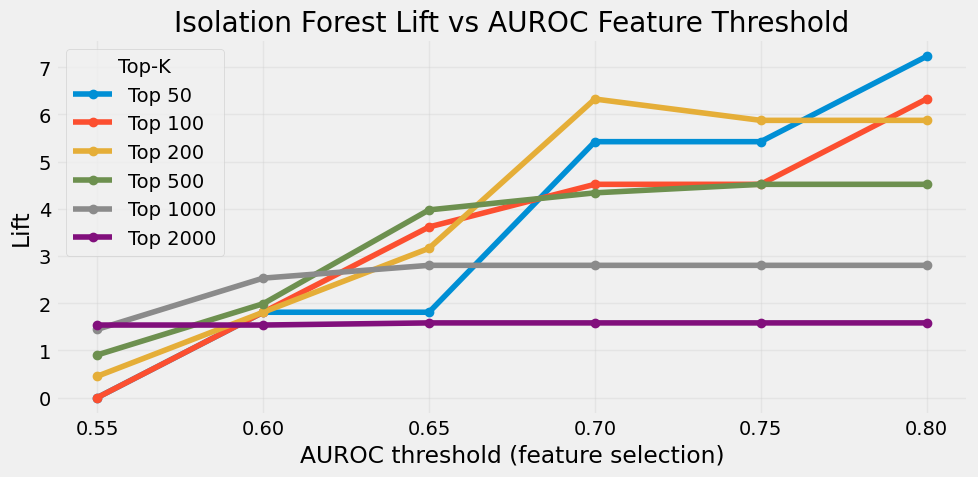

In [39]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

ks = [50, 100, 200, 500, 1000, 2000]
thresholds = [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
lift_records = []

for thresh in thresholds:
    feats = auroc_df[auroc_df['auroc'] >= thresh]['feature'].tolist()
    if not feats:
        continue

    subset_df = df[['label', 'billing_provider_npi'] + feats]
    X = subset_df[feats].dropna()
    idx = X.index

    iso = IsolationForest()
    scores = -iso.fit(X).score_samples(X)

    results = df.loc[idx, ['billing_provider_npi', 'label']].copy()
    results['anomaly_score'] = scores
    results = results.sort_values('anomaly_score', ascending=False).reset_index(drop=True)

    base_rate = results['label'].mean()
    for k in ks:
        if k > len(results):
            continue
        hits = results.head(k)['label'].sum()
        lift = (hits / k) / base_rate if base_rate > 0 else float('nan')
        lift_records.append({'auroc_thresh': thresh, 'k': k, 'lift': lift})

lift_df = pd.DataFrame(lift_records)

fig, ax = plt.subplots(figsize=(10, 5))
for k in ks:
    s = lift_df[lift_df['k'] == k]
    ax.plot(s['auroc_thresh'], s['lift'], marker='o', label=f'Top {k}')

ax.set_xlabel('AUROC threshold (feature selection)')
ax.set_ylabel('Lift')
ax.set_title('Isolation Forest Lift vs AUROC Feature Threshold')
ax.legend(title='Top-K')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ONE CLASS SVM

In [40]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

for thresh in [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
    feats = auroc_df[auroc_df['auroc'] >= thresh]['feature'].tolist()
    if not feats:
        print(f"\n=== AUROC >= {thresh} | no features, skipping ===")
        continue

    df2 = df[['label', 'billing_provider_npi'] + feats]
    features_model = [c for c in df2.columns if c not in exclude]

    X = df2[features_model].dropna()
    idx = X.index

    X_scaled = StandardScaler().fit_transform(X)

    oc_svm = OneClassSVM(kernel='rbf', nu=0.01)
    oc_svm.fit(X_scaled)
    scores = -oc_svm.score_samples(X_scaled)

    results = df2.loc[idx, ['billing_provider_npi', 'label']].copy()
    results['anomaly_score'] = scores
    results = results.sort_values('anomaly_score', ascending=False).reset_index(drop=True)

    base_rate = results['label'].mean()
    print(f"\n=== AUROC >= {thresh} | {len(feats)} features | Base rate: {base_rate:.4f} ===")
    for k in [50, 100, 200, 500, 1000, 2000]:
        if k > len(results):
            break
        top_k = results.head(k)
        hits = top_k['label'].sum()
        precision_k = hits / k
        lift = precision_k / base_rate if base_rate > 0 else float('nan')
        print(f"  Top {k:>4}  |  LEIE hits: {int(hits):>3}  |  Precision: {precision_k:.4f}  |  Lift: {lift:.2f}x")



=== AUROC >= 0.55 | 380 features | Base rate: 0.0111 ===
  Top   50  |  LEIE hits:   2  |  Precision: 0.0400  |  Lift: 3.61x
  Top  100  |  LEIE hits:   2  |  Precision: 0.0200  |  Lift: 1.81x
  Top  200  |  LEIE hits:   5  |  Precision: 0.0250  |  Lift: 2.26x
  Top  500  |  LEIE hits:   5  |  Precision: 0.0100  |  Lift: 0.90x
  Top 1000  |  LEIE hits:  10  |  Precision: 0.0100  |  Lift: 0.90x
  Top 2000  |  LEIE hits:  17  |  Precision: 0.0085  |  Lift: 0.77x

=== AUROC >= 0.6 | 192 features | Base rate: 0.0111 ===
  Top   50  |  LEIE hits:   1  |  Precision: 0.0200  |  Lift: 1.81x
  Top  100  |  LEIE hits:   1  |  Precision: 0.0100  |  Lift: 0.90x
  Top  200  |  LEIE hits:   6  |  Precision: 0.0300  |  Lift: 2.71x
  Top  500  |  LEIE hits:   8  |  Precision: 0.0160  |  Lift: 1.45x
  Top 1000  |  LEIE hits:  12  |  Precision: 0.0120  |  Lift: 1.08x
  Top 2000  |  LEIE hits:  19  |  Precision: 0.0095  |  Lift: 0.86x

=== AUROC >= 0.65 | 94 features | Base rate: 0.0111 ===
  Top   50  

# AUTOENCDOER (all features)

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import keras
import pandas as pd
from sklearn.preprocessing import StandardScaler

exclude = [
    'label', 'billing_provider_npi',
    'insufficient_history_flag', 'cohort_label',
    'months_observed', 'first_month', 'last_month',
    'span_months', 'missing_months_within_span',
    'fraction_months_observed', 'mean_gap_months', 'max_gap_months',
]

features = [col for col in df.columns if col not in exclude]

X = df[features].dropna()
y = df.loc[X.index, 'label'].values
npis = df.loc[X.index, 'billing_provider_npi'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
n_features = X_scaled.shape[1]
X_normal = X_scaled[y == 0]


In [48]:
model = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(n_features,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(n_features, activation='linear')
])
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_normal, X_normal, epochs=50, batch_size=64, validation_split=0.1, verbose=1)


Epoch 1/50


/Users/adityakoushik/Desktop/hmms/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9289 - val_loss: 0.6873
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6909 - val_loss: 0.5816
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5876 - val_loss: 0.5029
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5411 - val_loss: 0.4772
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5125 - val_loss: 0.4561
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4891 - val_loss: 0.4381
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4696 - val_loss: 0.4153
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4434 - val_loss: 0.3956
Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4247 - val_loss: 0.3800
Epoch 10/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4089 - val_loss: 0.3688
Epoch 11/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4012 - val_loss: 0.3605
Epoch 12/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3914 - val_loss: 0.3528


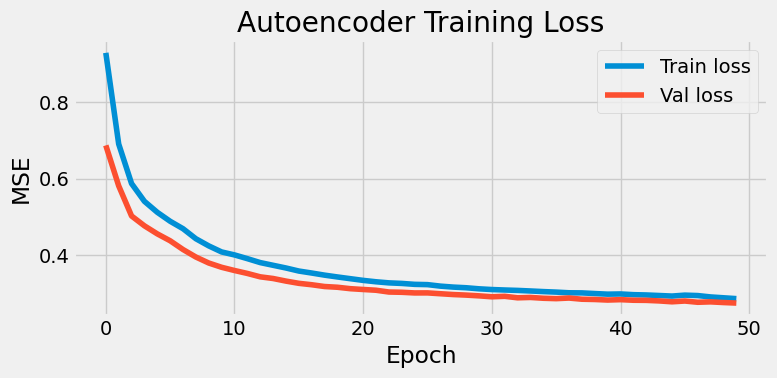

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Autoencoder Training Loss')
plt.legend()
plt.tight_layout()
plt.show()


In [50]:
reconstructions = model.predict(X_scaled)
recon_errors = np.mean(np.abs(X_scaled - reconstructions), axis=1)

results = pd.DataFrame({
    'billing_provider_npi': npis,
    'label': y,
    'recon_error': recon_errors
}).sort_values('recon_error', ascending=False).reset_index(drop=True)

base_rate = results['label'].mean()
print(f"Base rate (LEIE prevalence): {base_rate:.4f}\n")

for k in [50, 100, 200, 500, 1000, 2000]:
    if k > len(results):
        break
    top_k = results.head(k)
    hits = top_k['label'].sum()
    precision_k = hits / k
    lift = precision_k / base_rate if base_rate > 0 else float('nan')
    print(f"Top {k:>4}  |  LEIE hits: {int(hits):>3}  |  Precision: {precision_k:.4f}  |  Lift: {lift:.2f}x")


99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 942us/step
Base rate (LEIE prevalence): 0.0111

Top   50  |  LEIE hits:   0  |  Precision: 0.0000  |  Lift: 0.00x
Top  100  |  LEIE hits:   3  |  Precision: 0.0300  |  Lift: 2.71x
Top  200  |  LEIE hits:   8  |  Precision: 0.0400  |  Lift: 3.61x
Top  500  |  LEIE hits:  16  |  Precision: 0.0320  |  Lift: 2.89x
Top 1000  |  LEIE hits:  27  |  Precision: 0.0270  |  Lift: 2.44x
Top 2000  |  LEIE hits:  32  |  Precision: 0.0160  |  Lift: 1.45x


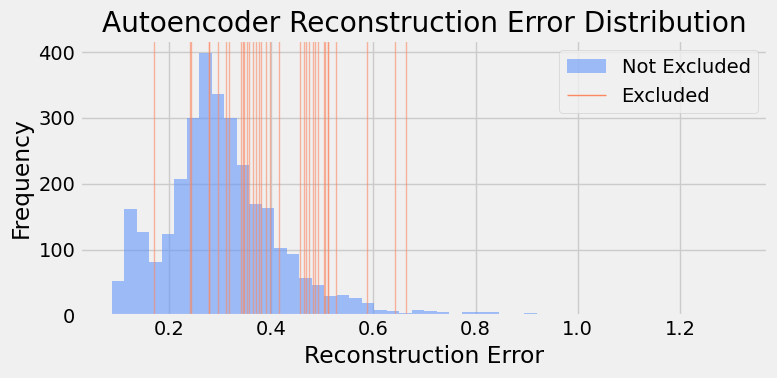

In [51]:
plt.figure(figsize=(8, 4))
plt.hist(results[results['label']==0]['recon_error'], bins=50, alpha=0.6, color='#6497F9', label='Not Excluded')
for err in results[results['label']==1]['recon_error']:
    plt.axvline(x=err, color='#FB8861', alpha=0.6, linewidth=1)
plt.axvline(x=float('nan'), color='#FB8861', linewidth=1, label='Excluded')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.title('Autoencoder Reconstruction Error Distribution')
plt.legend()
plt.tight_layout()
plt.show()


# Autoencoder thresh

In [64]:
feats = auroc_df[auroc_df['auroc'] >= 0.65]['feature'].tolist()

X = df[feats].dropna()
y = df.loc[X.index, 'label'].values
npis = df.loc[X.index, 'billing_provider_npi'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
n_features = X_scaled.shape[1]
X_normal = X_scaled[y == 0]


In [65]:
X_normal.shape

(3127, 94)

In [66]:
model = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(n_features,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(n_features, activation='linear')
])
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_normal, X_normal, epochs=50, batch_size=64, validation_split=0.1, verbose=1)


Epoch 1/50


/Users/adityakoushik/Desktop/hmms/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.9740 - val_loss: 0.6331
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8457 - val_loss: 0.5446
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6860 - val_loss: 0.4370
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5362 - val_loss: 0.3479
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4490 - val_loss: 0.3038
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4086 - val_loss: 0.2819
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3856 - val_loss: 0.2739
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3668 - val_loss: 0.2606
Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3475 - val_loss: 0.2558
Epoch 10/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3338 - val_loss: 0.2502
Epoch 11/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3203 - val_loss: 0.2443
Epoch 12/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3051 - val_loss: 0.2273


In [67]:
reconstructions = model.predict(X_scaled)
recon_errors = np.mean(np.abs(X_scaled - reconstructions), axis=1)

results = pd.DataFrame({
    'billing_provider_npi': npis,
    'label': y,
    'recon_error': recon_errors
}).sort_values('recon_error', ascending=False).reset_index(drop=True)

base_rate = results['label'].mean()
print(f"Base rate (LEIE prevalence): {base_rate:.4f}\n")

for k in [50, 100, 200, 500, 1000, 2000]:
    if k > len(results):
        break
    top_k = results.head(k)
    hits = top_k['label'].sum()
    precision_k = hits / k
    lift = precision_k / base_rate if base_rate > 0 else float('nan')
    print(f"Top {k:>4}  |  LEIE hits: {int(hits):>3}  |  Precision: {precision_k:.4f}  |  Lift: {lift:.2f}x")


99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step
Base rate (LEIE prevalence): 0.0111

Top   50  |  LEIE hits:   3  |  Precision: 0.0600  |  Lift: 5.42x
Top  100  |  LEIE hits:   5  |  Precision: 0.0500  |  Lift: 4.52x
Top  200  |  LEIE hits:  10  |  Precision: 0.0500  |  Lift: 4.52x
Top  500  |  LEIE hits:  23  |  Precision: 0.0460  |  Lift: 4.16x
Top 1000  |  LEIE hits:  32  |  Precision: 0.0320  |  Lift: 2.89x
Top 2000  |  LEIE hits:  34  |  Precision: 0.0170  |  Lift: 1.54x


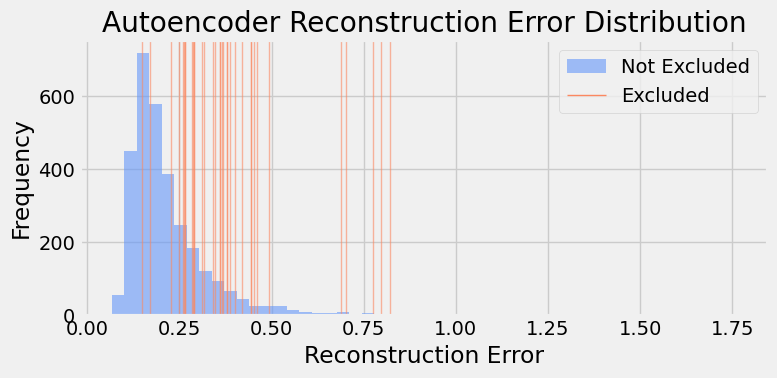

In [68]:
plt.figure(figsize=(8, 4))
plt.hist(results[results['label']==0]['recon_error'], bins=50, alpha=0.6, color='#6497F9', label='Not Excluded')
for err in results[results['label']==1]['recon_error']:
    plt.axvline(x=err, color='#FB8861', alpha=0.6, linewidth=1)
plt.axvline(x=float('nan'), color='#FB8861', linewidth=1, label='Excluded')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.title('Autoencoder Reconstruction Error Distribution')
plt.legend()
plt.tight_layout()
plt.show()


PR-AUC (5-fold CV): 0.0770  |  Base rate: 0.0111

Top   50  |  LEIE hits:   6  |  Precision: 0.1200  |  Lift: 10.84x
Top  100  |  LEIE hits:  13  |  Precision: 0.1300  |  Lift: 11.74x
Top  200  |  LEIE hits:  17  |  Precision: 0.0850  |  Lift: 7.68x
Top  500  |  LEIE hits:  23  |  Precision: 0.0460  |  Lift: 4.16x
Top 1000  |  LEIE hits:  28  |  Precision: 0.0280  |  Lift: 2.53x
Top 2000  |  LEIE hits:  30  |  Precision: 0.0150  |  Lift: 1.36x


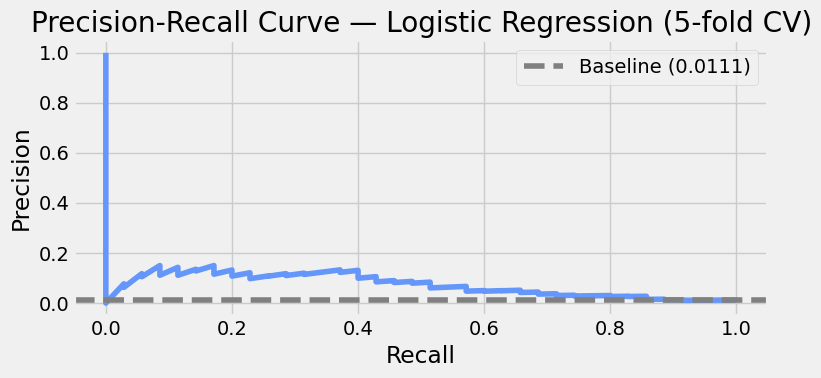

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.model_selection import StratifiedKFold
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_probs = np.zeros(len(y))
all_labels = np.zeros(len(y))

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y)):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    lr = LogisticRegression(class_weight='balanced', max_iter=1000)
    lr.fit(X_train, y_train)
    all_probs[test_idx] = lr.predict_proba(X_test)[:, 1]
    all_labels[test_idx] = y_test

pr_auc = average_precision_score(all_labels, all_probs)
base_rate = all_labels.mean()
print(f"PR-AUC (5-fold CV): {pr_auc:.4f}  |  Base rate: {base_rate:.4f}\n")

results_lr = pd.DataFrame({'label': all_labels, 'prob': all_probs}).sort_values('prob', ascending=False).reset_index(drop=True)

for k in [50, 100, 200, 500, 1000, 2000]:
    if k > len(results_lr):
        break
    hits = results_lr.head(k)['label'].sum()
    precision_k = hits / k
    lift = precision_k / base_rate if base_rate > 0 else float('nan')
    print(f"Top {k:>4}  |  LEIE hits: {int(hits):>3}  |  Precision: {precision_k:.4f}  |  Lift: {lift:.2f}x")

precision, recall, _ = precision_recall_curve(all_labels, all_probs)
plt.figure(figsize=(8, 4))
plt.plot(recall, precision, color='#6497F9')
plt.axhline(base_rate, color='gray', linestyle='--', label=f'Baseline ({base_rate:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Logistic Regression (5-fold CV)')
plt.legend()
plt.tight_layout()
plt.show()
